In [93]:
from langgraph.graph import StateGraph , START ,END
from langchain_core.messages import HumanMessage , SystemMessage
from langchain_nvidia_ai_endpoints import ChatNVIDIA
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from typing import TypedDict , Literal
from pydantic import BaseModel , Field
import operator

In [94]:
load_dotenv()

True

In [95]:
class TweetState(TypedDict):

    topic:str
    tweet:str
    evaluation : Literal['approved','needs_improvement']
    feedback : str
    iteratation : int
    max_iteratation : int


In [96]:
generator_model = ChatGoogleGenerativeAI(model='gemini-3.6-flash')
evalutation_model = ChatGoogleGenerativeAI(model='gemini-3.6-flash')
optimiser_model = ChatGoogleGenerativeAI(model='gemini-3.6-flash')

In [97]:
class EvaluationSchema(BaseModel):
    evaluation : Literal['approved','needs_improvement'] = Field(...,description="final evaluation result")
    feedback : str = Field(...,description="feedback for the tweet")

In [98]:
structured_evaluator = evalutation_model.with_structured_output(EvaluationSchema)

In [99]:
def tweet_generator(state:TweetState):

     messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

Rules:
- Do NOT use question-answer format.
- Max 280 characters.
- Use observational humor, irony, sarcasm, or cultural references.
- Think in meme logic, punchlines, or relatable takes.
- Use simple, day to day english
""")
    ]
     result = generator_model.invoke(messages).content

     return {'tweet':result}

# ------------------------------------------------------------evaluation

def tweet_evaluator(state:TweetState):

     # prompt
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
Evaluate the following tweet:

Tweet: "{state['tweet']}"

Use the criteria below to evaluate the tweet:

1. Originality – Is this fresh, or have you seen it a hundred times before?  
2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
3. Punchiness – Is it short, sharp, and scroll-stopping?  
4. Virality Potential – Would people retweet or share it?  
5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

### Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"  
- feedback: One paragraph explaining the strengths and weaknesses 
""")
]
    result = structured_evaluator.invoke(messages)

    return {'evaluation':result.evaluation , 'feedback':result.feedback}

# ------------------------------------------------------------optimization

def tweet_optmiser(state:TweetState):

     messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")
    ]

     result = optimiser_model.invoke(messages).content
     iteration = state['iteratation'] + 1

     return {'tweet':result,'iteratation':iteration}

# --------------------------------------------------condition state
def route_evaluation(state:TweetState):
     if state['evaluation'] == 'approved' or state['iteratation'] >= state['max_iteratation']:
          return 'approved'
     else:
          return 'needs_improvement'

In [100]:
graph = StateGraph(TweetState)

graph.add_node('tweet_generator',tweet_generator)
graph.add_node('tweet_evaluator',tweet_evaluator)
graph.add_node('tweet_optmiser',tweet_optmiser)

graph.add_edge(START,'tweet_generator')
graph.add_edge('tweet_generator','tweet_evaluator')


graph.add_conditional_edges('tweet_evaluator',route_evaluation,{'approved':END,'needs_improvement':'tweet_optmiser'})
graph.add_edge('tweet_optmiser','tweet_evaluator')


workflow = graph.compile()

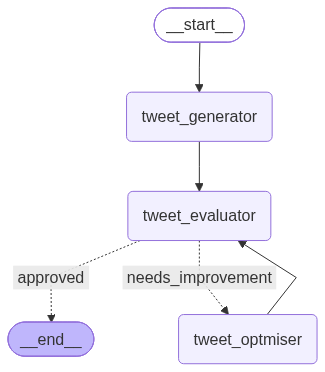

In [101]:
workflow

In [102]:
initial_flow = {
    'topic':'indian Educatation',
    'iteratation':1,
    'max_iteratation':5
}

workflow.invoke(initial_flow)

{'topic': 'indian Educatation',
 'tweet': [{'type': 'text',
   'text': 'OpenAI spent $10 billion training an AI to hallucinate confident nonsense, accidentally recreating every student sitting for an Indian board exam.',
   'extras': {'signature': 'EuMnCuAnARFNMg/XrI6B6daIBVKCFXmX81vdhLComyMtr7D+XNfKKjQhxfLDfgvs1+AmnsxYKzpHsC1v9AExBBLk6r4Z1WbxQ02G/csq92Pf+zixSrHtzhjamelAQC/sS3ssiK05NRIcXmBHwmFlIlsN12YpJSnujCeE+nbh9BYTreow8G9qavkU8QsRM6oFaFS95huQoLPw/OHZupUdCE4E3vHQeCUSlnb44isNIoBcTCN99NLGJIBVNSE8f3lLslwzWEuxHR8RgpYLoWW+7XNn4Lh0yXmpPfm6LqSG/JVtIC5awy3rh9aRBkXrVZccDHWV39qYLlXZfFQeYQhbavNunO/98vylqPDnuZdYee0ALwELqAZd8cMP4uBZxN0kuWVK70rmlzqfHo94fPWhH1AmB3L8W4snoBvcULUEb7dmqscWlD8CKY+0q3+DhD446uRJLV9t2yimIpiaW27UO8ErQT6AibQECxEKhBj6uVOa7P/h0V5ftA2o1tlJi6HqUk8bEBWvuk+rubPcOL+NIvc39CpNrW4I2OX56Yf4+tpp59D8s/txYQPKyzQR0uslZtl2ed6zNH8lprHK7j01dqURjeb99P+ybtw45XPbMcS7iKRF+TEb6Rf/Ce3G6+fEYJvJFdJ5LzZC0w+5Ti+YKiQkp3lrlvQqK3aujMQpF2anTvPbv5Fps7jf1AjuTdEXfbDIXovpzaNJ7aYImIX9S57isyQQL+oa4rIHwImqBXSkSzl